# Weather Pattern Clustering with Temporal Validation

Refactored a weather-clustering workflow for 1.59 million minute-level records, using a 158,726-row sample. Added circular wind-direction features, temporal validation, training-only preprocessing and data-driven selection of cluster count. The chosen two-cluster solution achieved a held-out silhouette score of 0.325, with stability checks across random seeds. Documented the dataset mirror and limitations of interpreting unsupervised groups.

This notebook reviews saved results. The experiment script was executed separately. Enable the optional rerun only after configuring your dataset.

## Method

Sampled every tenth row from 1,587,257 minute-level observations. Encoded wind directions as sine/cosine, excluded identifier columns, and fitted imputation and scaling on an earlier time period. Selected K from 2–12 using validation silhouette, then assessed a later test period and stability across random seeds.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
metrics = json.loads((root / 'results' / 'metrics.json').read_text(encoding='utf8'))
if 'test_results' in metrics:
    display(pd.DataFrame(metrics['test_results']).T)
else:
    display(pd.DataFrame({'value': {k:v for k,v in metrics.items() if isinstance(v,(str,int,float))}}))

,value
source_url,https://media.githubusercontent.com/media/devm...
source_note,Public mirror of the course dataset; not retri...
input_sha256,b0e075e9655b505afe40b75b53dcc7eeab70677ead4c3e...
source_rows,1587257
sampled_rows,158726
selected_k,2
selection_metric,validation silhouette
test_silhouette,0.324778
test_davies_bouldin,1.355998
runtime_seconds,5.937331


## Recorded environment and data provenance

In [2]:
display(metrics.get('environment', {}))
print('Data fingerprint:', metrics.get('input_sha256', metrics.get('audit',{}).get('input_sha256','see dataset checksums')))

{'python': '3.12.2',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'sklearn': '1.9.1',
 'scipy': '1.18.1',
 'seed': 42}

Data fingerprint: b0e075e9655b505afe40b75b53dcc7eeab70677ead4c3e98c58cbd8b8be82177


## Figures

select_k.png


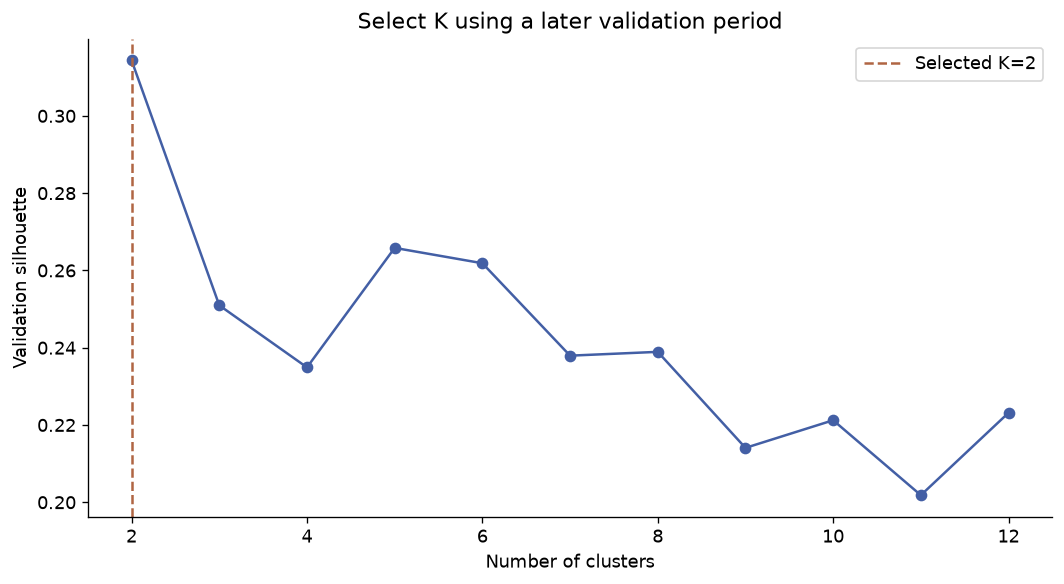

weather_clusters.png


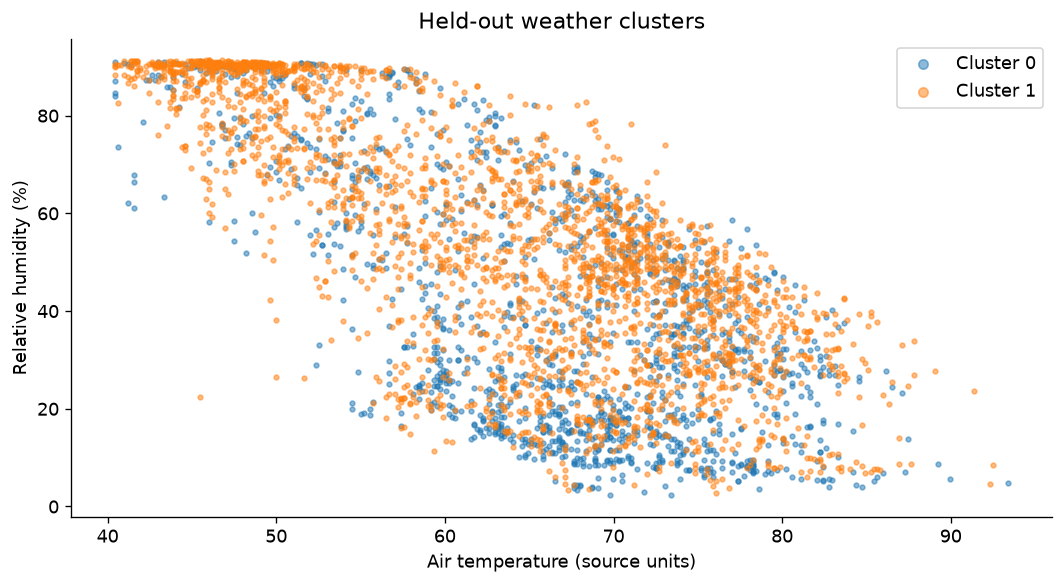

In [3]:
for figure in sorted((root / 'results').glob('*.png')):
    print(figure.name)
    display(Image(filename=str(figure)))

## Interpretation and limitations

Clustering has no labeled classification accuracy. The selected two-cluster solution has test silhouette 0.325 and cross-seed adjusted Rand agreement of 0.977 and 0.965. These summarize mathematical separation/stability, not meteorological ground truth or performance at other stations. Original notebook is collaborative coursework; preserve original collaborator credits if publishing the coursework.

## Optional full rerun

Adjust the dataset path in the command. This may download files or train a model and can take time. Results below are never produced from synthetic placeholder data.

In [4]:
RERUN_EXPERIMENT = False
if RERUN_EXPERIMENT:
    import subprocess, sys, shlex
    command = 'python analyze.py --data data/minute_weather.csv --out results'
    subprocess.run([sys.executable] + shlex.split(command)[1:], cwd=root, check=True)